In [43]:
import numpy as np 
import xarray as xr
from pathlib import Path 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec
import sys
import warnings 

DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/v2.0/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)
from helpers import plot_progress, plot_sampling

In [44]:
RESULTS_DIR = "./results_100_measurements/"

### P1 : Sample a composition and temperature combination from a 3D space

In [45]:
def get_immediate_subdirs(path):
    return [str(p) for p in Path(path).iterdir() if p.is_dir()]
def get_sorted_nc_files(path):
    files = [p for p in Path(path).iterdir() if p.is_file() and p.suffix == ".nc"]
    # sort by the integer after 'ds_' and before '.nc'
    files.sort(key=lambda p: int(p.stem.split("_")[1]))
    return [str(f) for f in files]

In [46]:
def plot_progress_p1(ds, 
                  design_space_variable="design_space", 
                  grid_variable="design_space_grid", 
                  design_space_dim="ds_dim", 
                  composition_variables=["protein", "glycerol"],
                  temperature_variable="temperature",
                  labels_variable="phases",
                  phase_probability_variable="phase_entropy",
                  ):
    """Plot cost and entropy in 3D."""
    fig = plt.figure(figsize=(4*3, 4))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=1e-5)

    ax_sampling = fig.add_subplot(gs[0, 0], projection="3d")
    x = ds[design_space_variable].sel({design_space_dim:composition_variables[0]}).values
    y = ds[design_space_variable].sel({design_space_dim:composition_variables[1]}).values
    z = ds[design_space_variable].sel({design_space_dim:temperature_variable}).values
    ax_sampling.scatter(x, y, z, c=ds[labels_variable].values)

    xg = ds[grid_variable].sel({design_space_dim:composition_variables[0]}).values
    yg = ds[grid_variable].sel({design_space_dim:composition_variables[1]}).values
    zg = ds[grid_variable].sel({design_space_dim:temperature_variable}).values    

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax_entropy = fig.add_subplot(gs[0, 1], projection="3d")
    mappable = ax_entropy.scatter(xg, yg, zg,
        c=ds[phase_probability_variable].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(phase_probability_variable)

    for ax in [ax_sampling, ax_entropy]:
        ax.set_xlabel(composition_variables[0])
        ax.set_ylabel(composition_variables[1])
        ax.set_zlabel(temperature_variable, labelpad=1)
        ax.set_xlim(0, 80)
        ax.set_ylim(0, 12)
        ax.set_zlim(0, 50)
    
    # Shrink extra white space manually
    ax_sampling.set_position([0.05, 0.1, 0.4, 0.8])  # [left, bottom, width, height]
    ax_entropy.set_position([0.4, 0.1, 0.4, 0.8])
    cax.set_position([0.8, 0.25, 0.01, 0.5])
    
    return fig, [ax_sampling, ax_entropy, cax] 

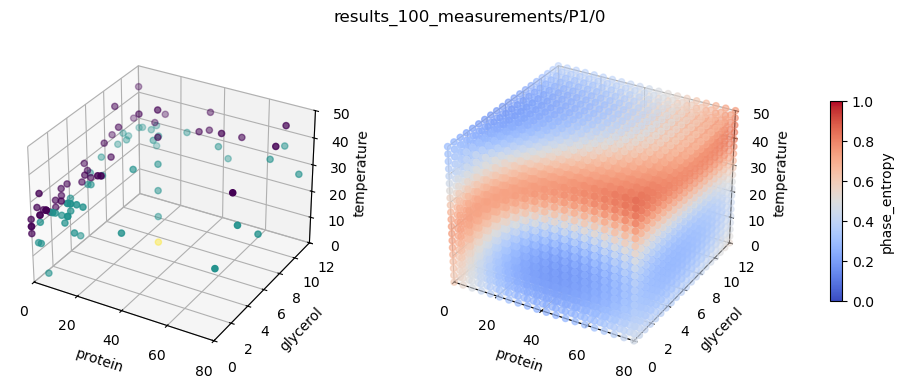

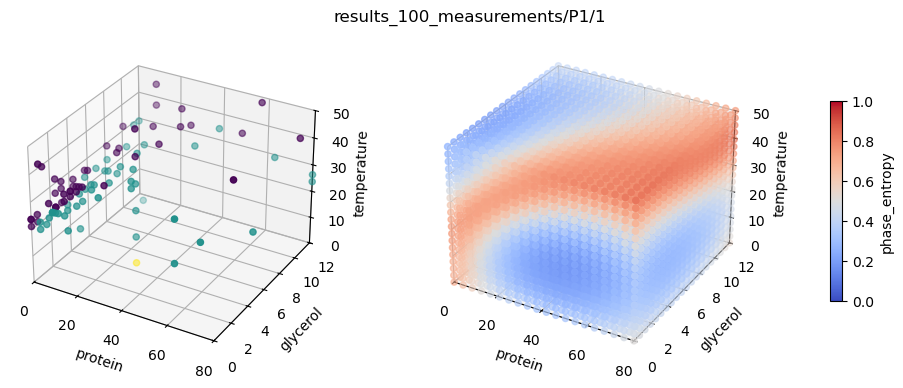

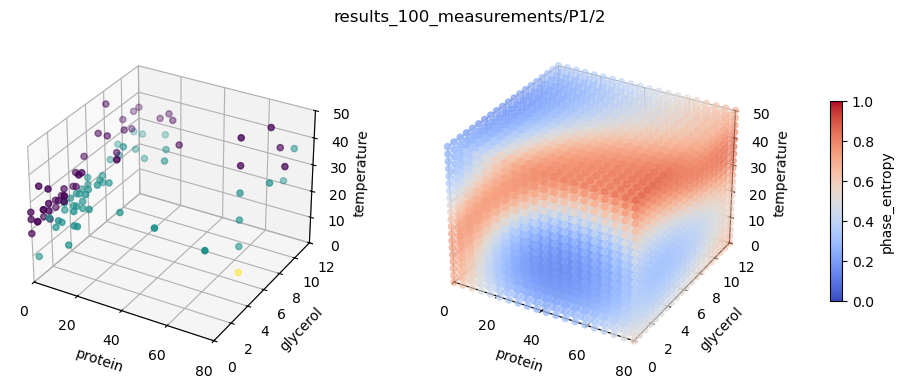

In [47]:
pipeline_direc = f"./{RESULTS_DIR}/P1/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress_p1(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
    )
    fig.suptitle(direc)
    plt.show()

## P2 : Single composition and temperature with feasibility scaled acquisition

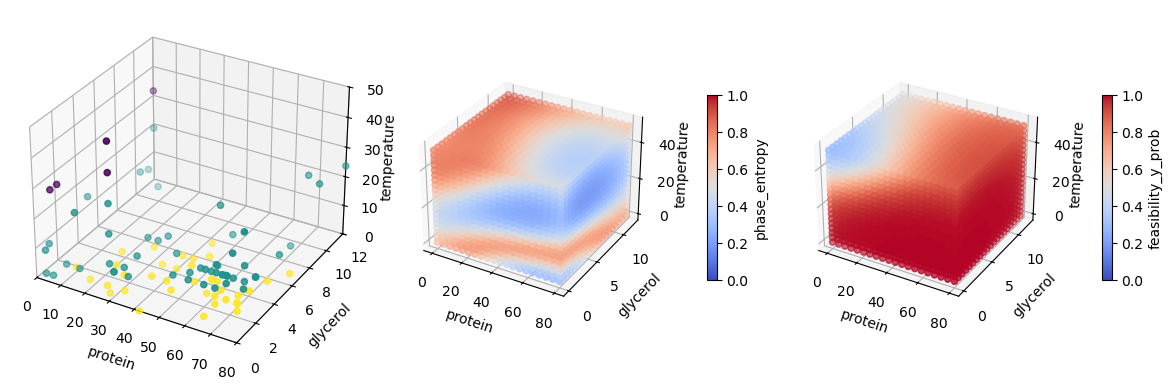

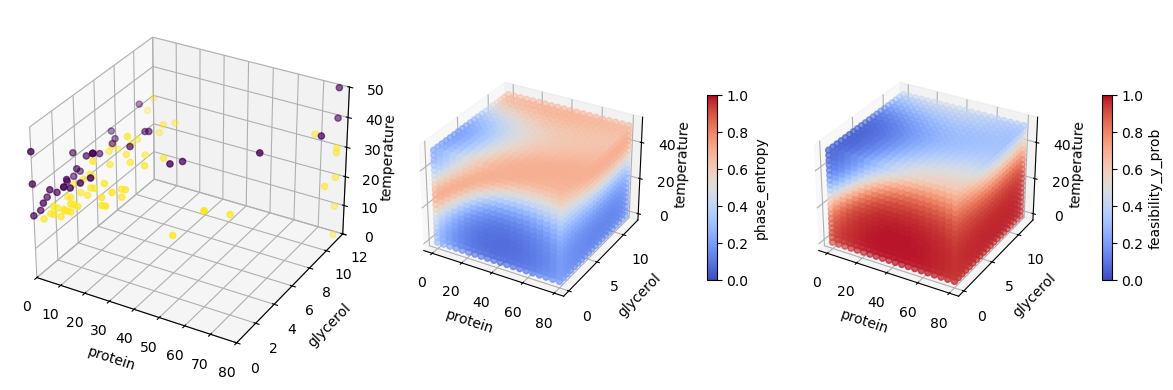

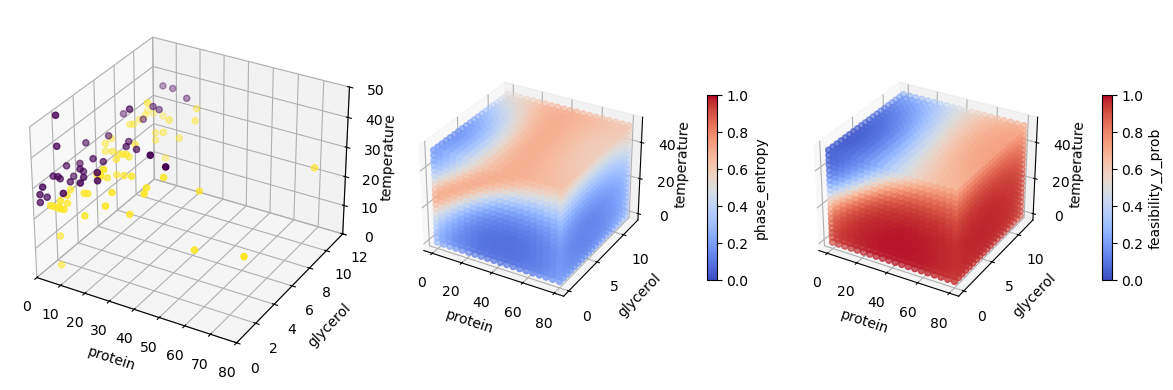

In [48]:
pipeline_direc = f"./{RESULTS_DIR}/P2/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P3 : Single composition and batch temperature based on FWHM near phase boundaries

In [49]:
pipeline_direc = f"./{RESULTS_DIR}/P3/"
run_direcs = get_immediate_subdirs(pipeline_direc)

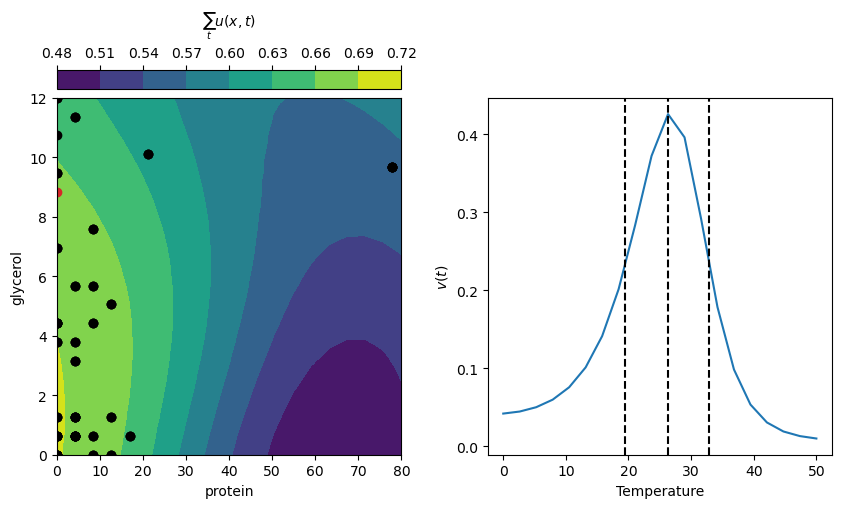

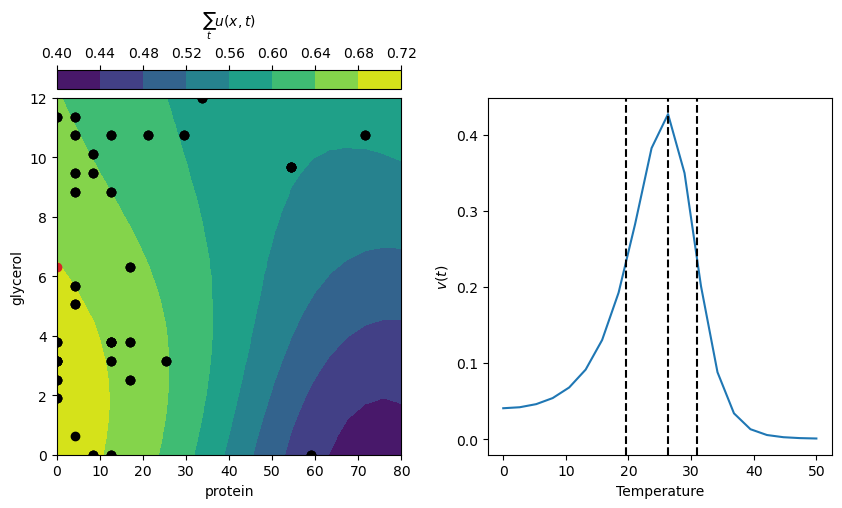

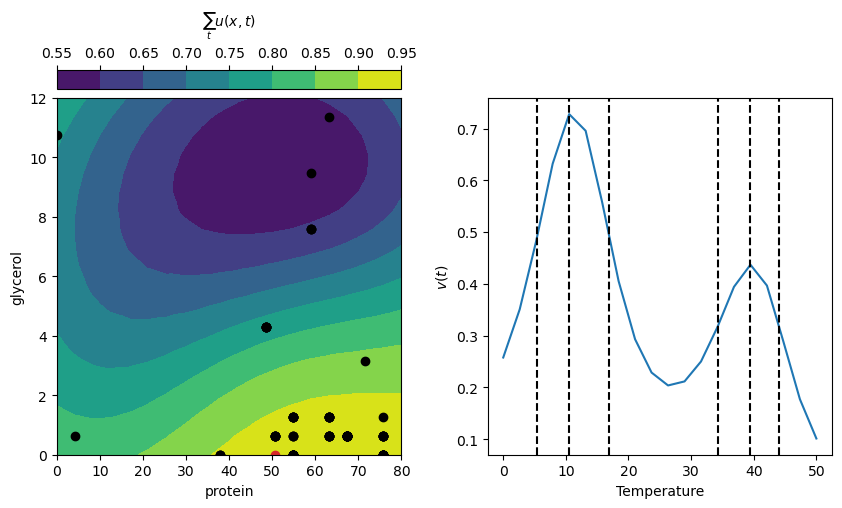

In [50]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    plt.show()

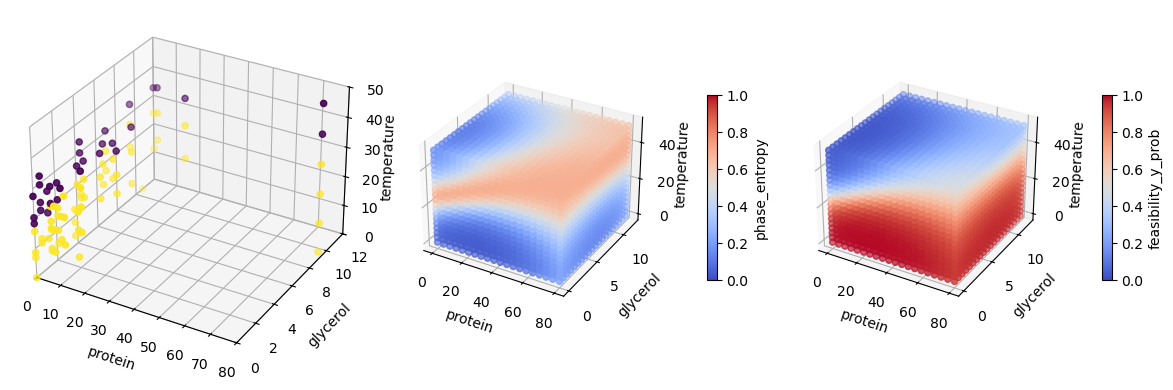

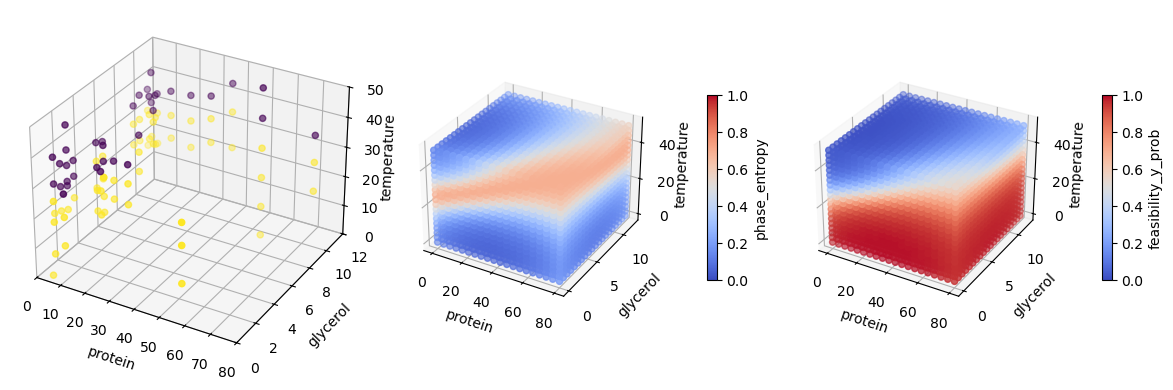

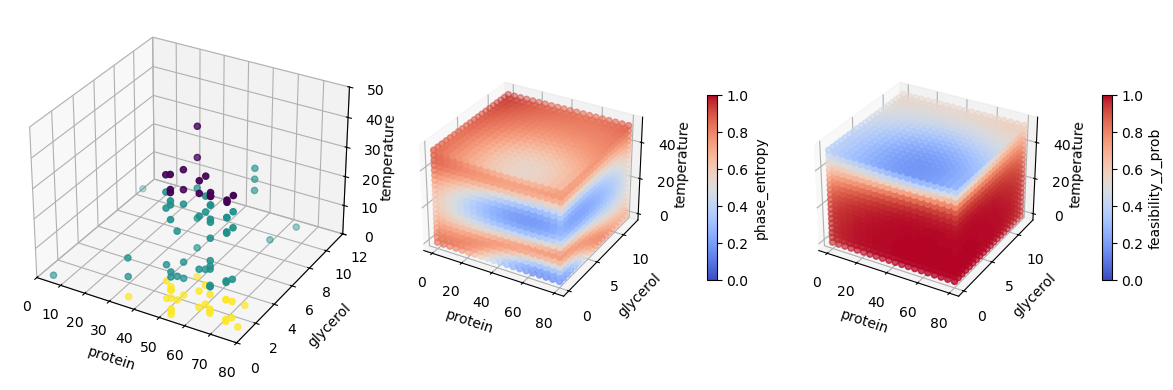

In [51]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P4: Single composition with batch of times adaptively selected through acquisition optimization

In [52]:
pipeline_direc = f"./{RESULTS_DIR}/P4/"
run_direcs = get_immediate_subdirs(pipeline_direc)

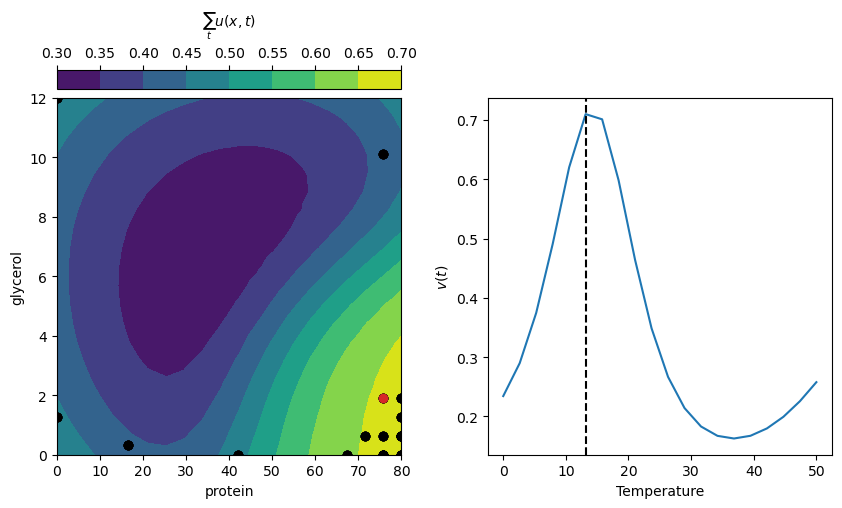

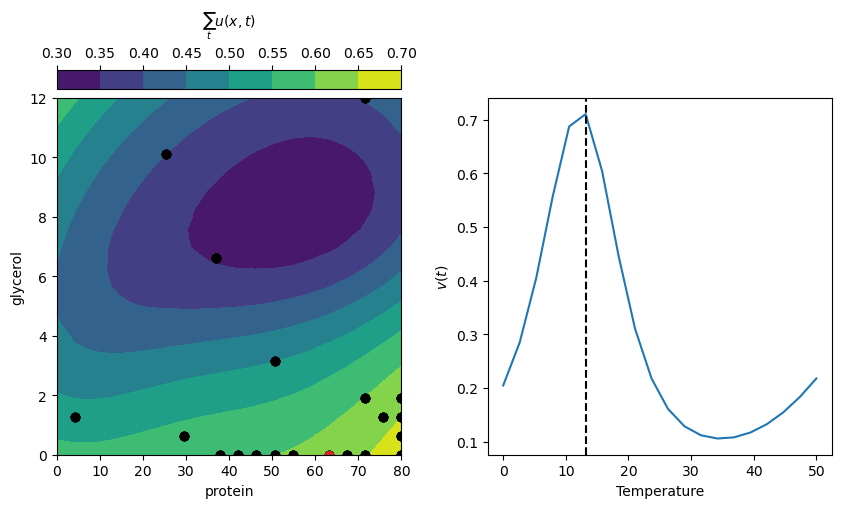

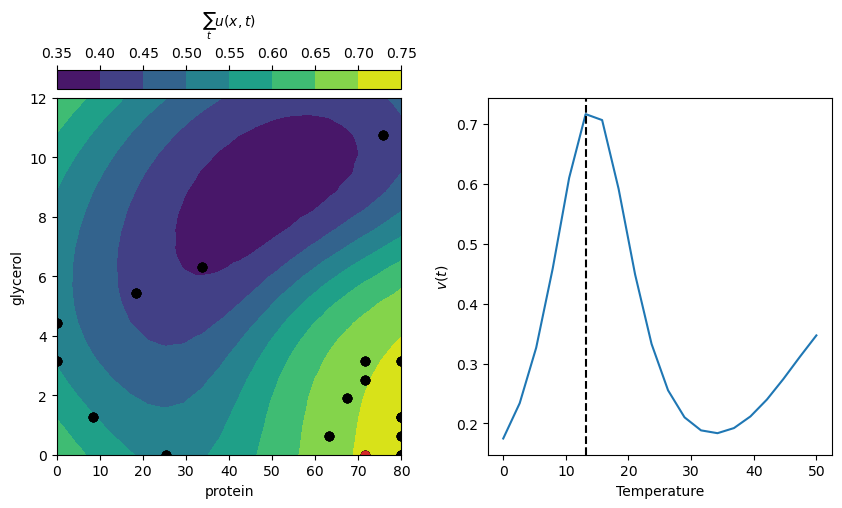

In [53]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    plt.show()

In [54]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:                        (q: 281, ds_dim: 3, protein_glycerol_d: 2,
                                    sample: 100, ds_grid: 8000,
                                    protein_glycerol_n: 400,
                                    composition_next_n: 1, phase_n_classes: 3,
                                    feasibility_n_classes: 2,
                                    temperature_n: 20, temperature_next_n: 1)
Coordinates:
  * q                              (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                         (ds_dim) <U11 132B 'protein' ... 'glycerol'
  * protein_glycerol_d             (protein_glycerol_d) <U8 64B 'protein' 'gl...
Dimensions without coordinates: sample, ds_grid, protein_glycerol_n,
                                composition_next_n, phase_n_classes,
                                feasibility_n_classes, temperature_n,
                                temperature_next_n
Data variables: (12/29)
    I                              (sample, q) float64 225kB 1.95 1.937 ... 1.0
    I_noiseless                    (sample, q) float64 225kB 1.95 1.937 ... 1.0
    dI                             (sample, q) float64 225kB 0.0 0.0 ... 0.0 0.0
    design_space                   (sample, ds_dim) float64 2kB 18.3 0.0 ... 0.0
    phases                         (sample) int64 800B 2 1 1 1 0 0 ... 2 2 2 2 2
    design_space_grid              (ds_grid, ds_dim) float64 192kB 0.0 ... 12.0
    ...                             ...
    feasibility_cost               (ds_grid) float64 64kB 0.01283 ... 0.2747
    temperature_utility            (temperature_n) float64 160B 0.1754 ... 0....
    temperature_domain             (temperature_n) float64 160B 0.0 ... 50.0
    temperature_cost               (temperature_n) float64 160B 0.002578 ... ...
    temperature_utility_with_cost  (temperature_n) float64 160B 0.1749 ... 0.347
    temperature_next               (temperature_next_n) float64 8B 13.16
Attributes:
    components:      ['protein', 'temperature', 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

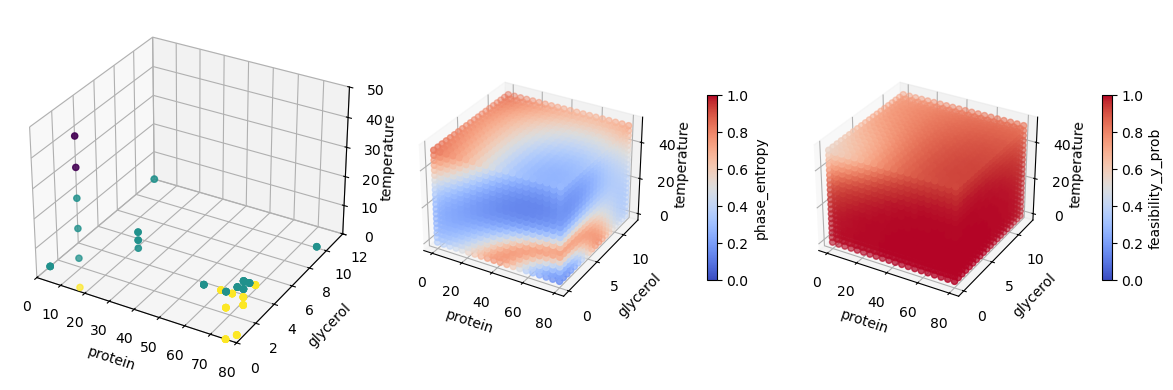

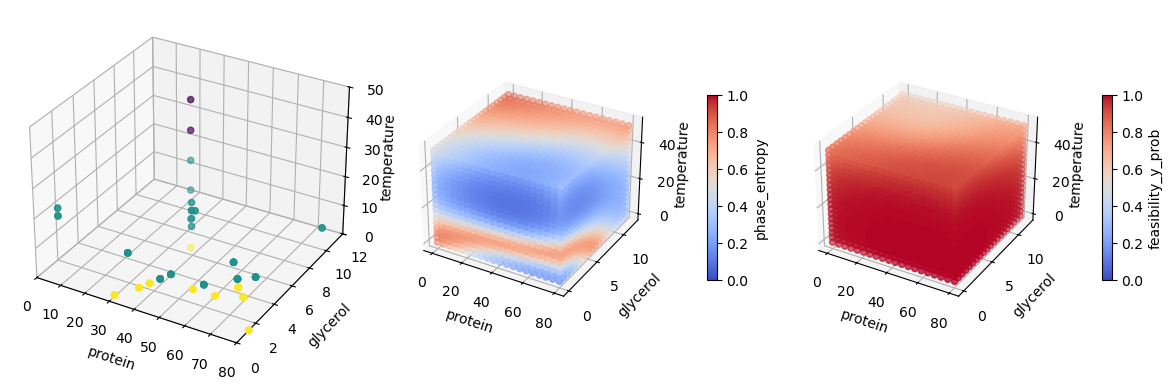

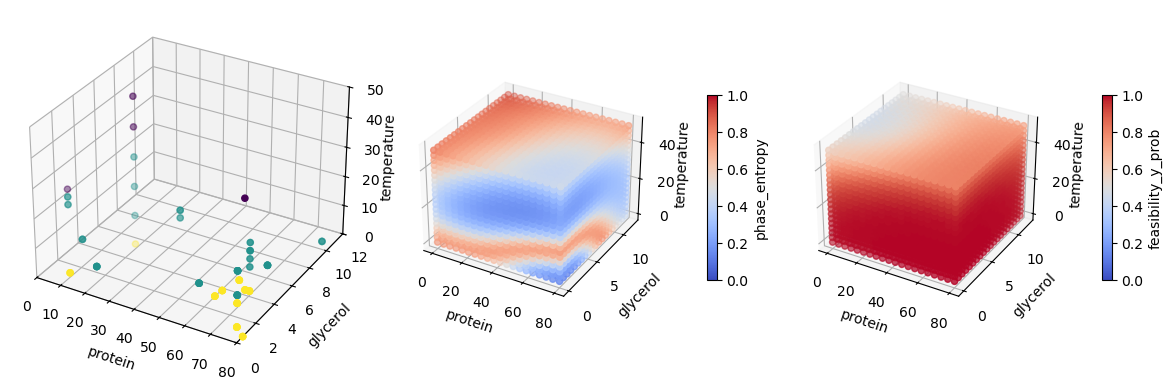

In [55]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

## P5: Single composition with temperatures sampled linearly between the feasible region

In [56]:
pipeline_direc = f"./{RESULTS_DIR}/P5/"
run_direcs = get_immediate_subdirs(pipeline_direc)

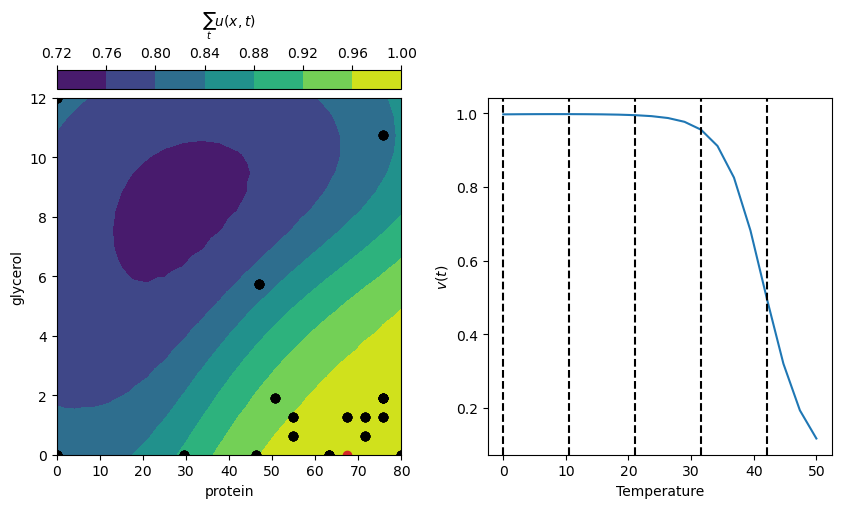

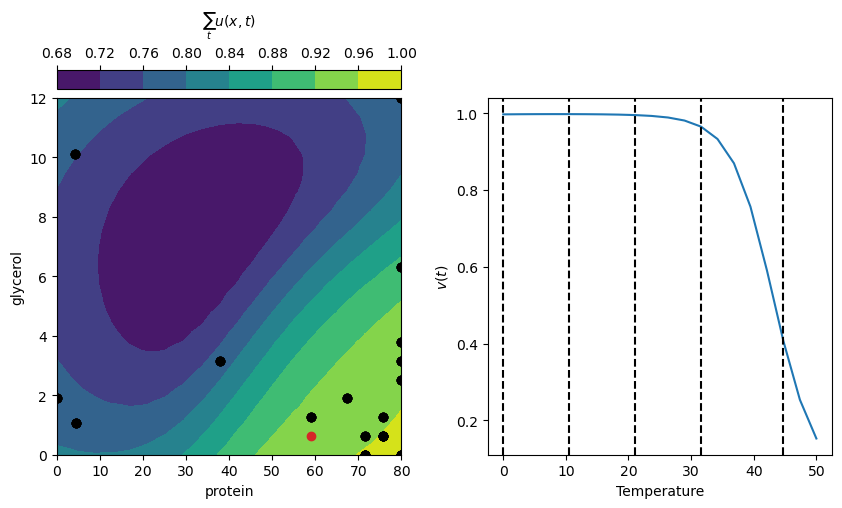

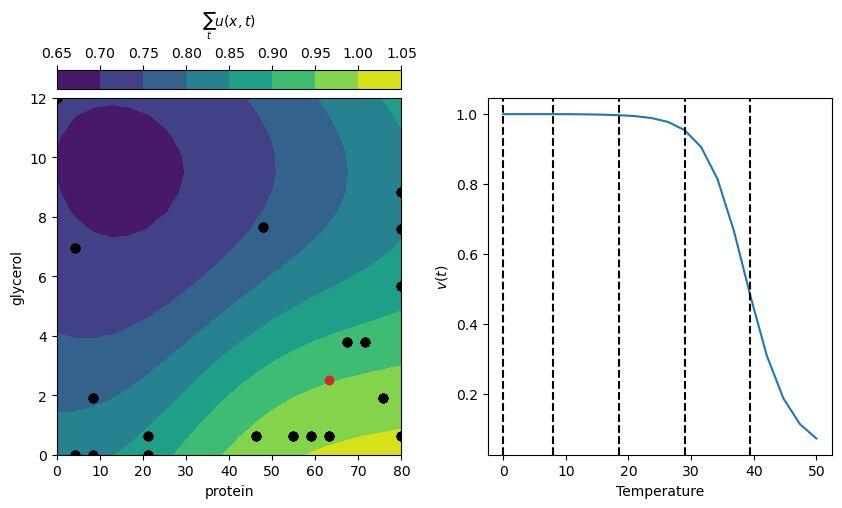

In [57]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility",
        "temperature_next"
    )
    plt.show()

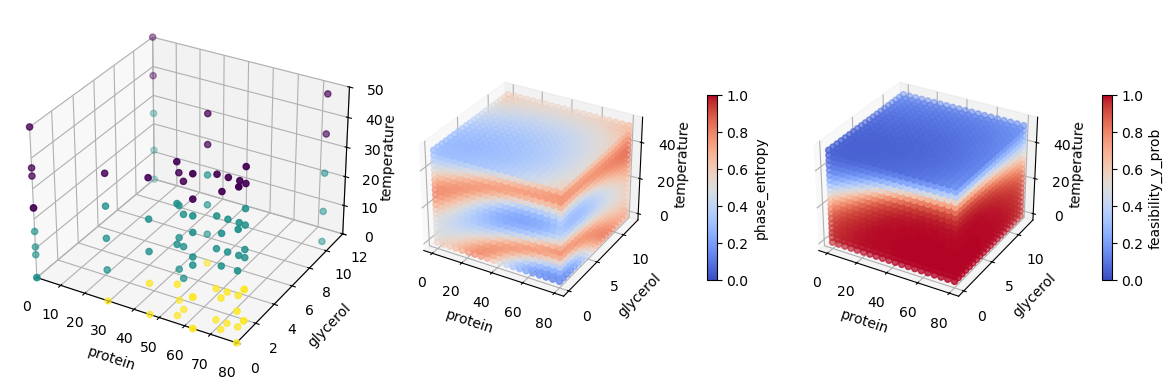

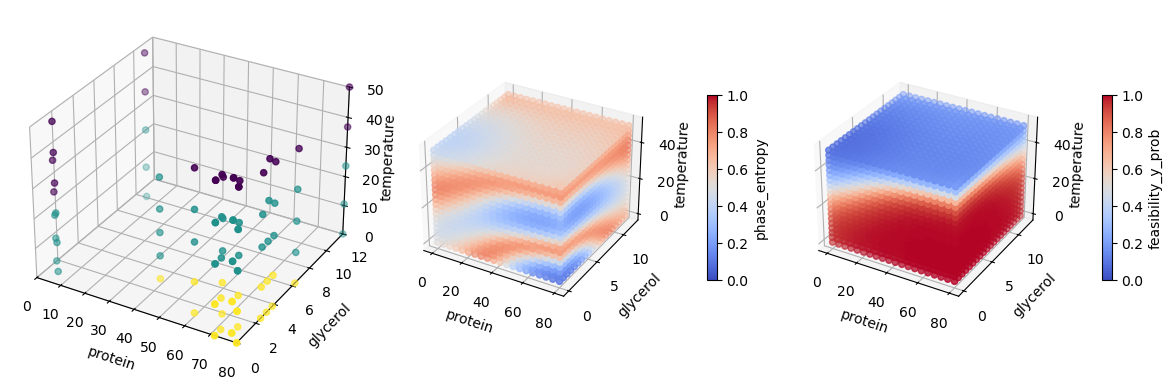

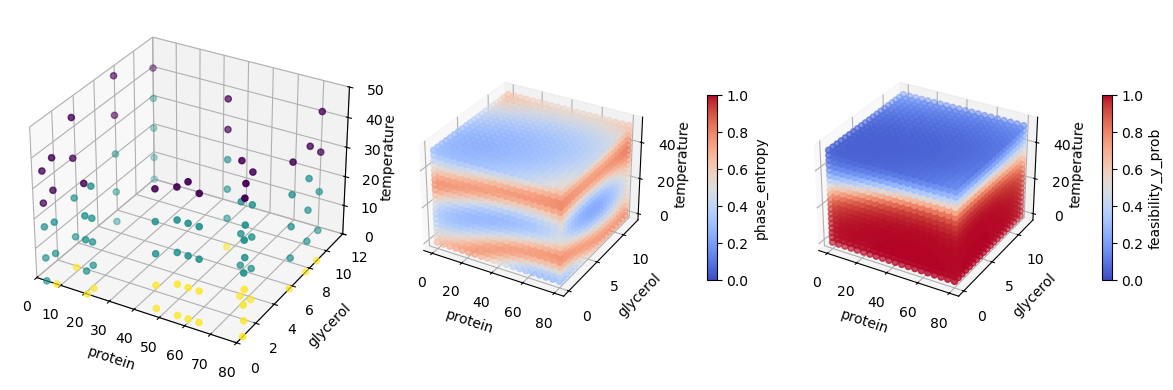

In [58]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    plt.show()

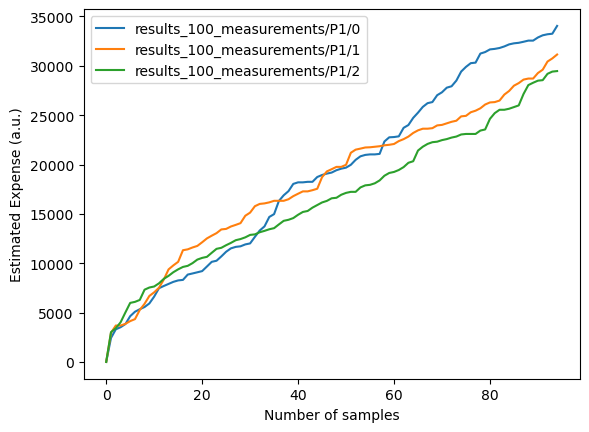

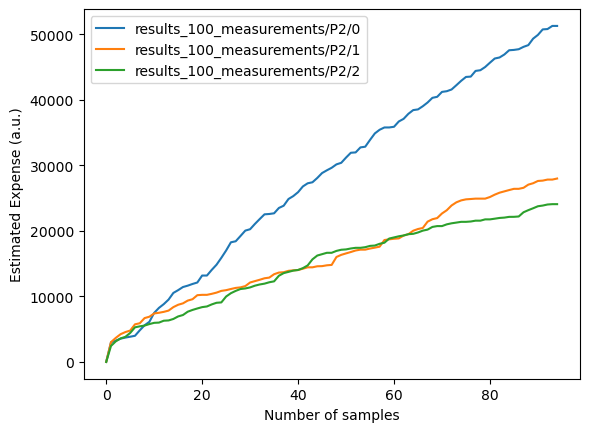

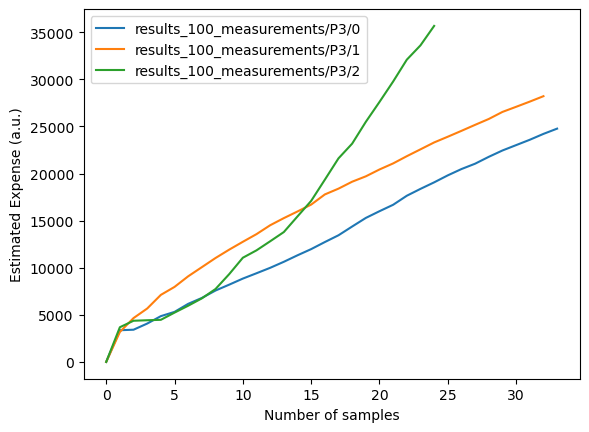

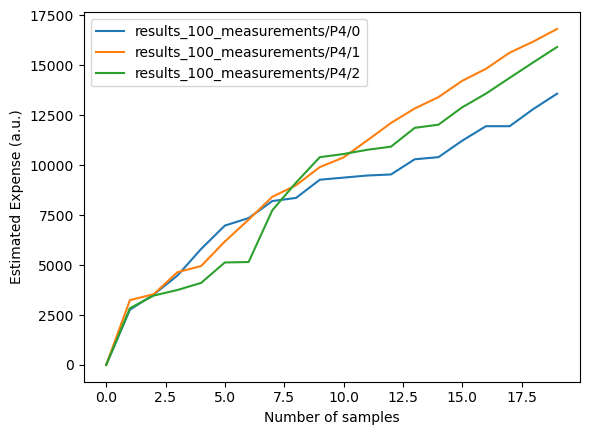

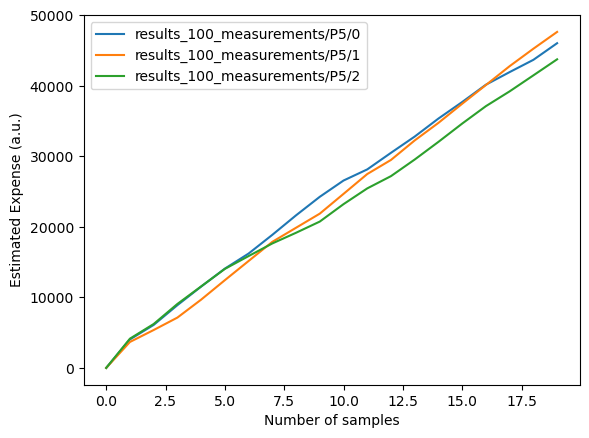

In [59]:
pipeline_direcs = sorted(get_immediate_subdirs(RESULTS_DIR))

for pdirec in pipeline_direcs:
    fig, ax = plt.subplots()
    for j in range(3):
        direc = pdirec+f"/{j}"
        try:
            expense = np.load(direc+"/expense.npy")
            ax.plot(
                np.arange(expense.shape[0]), 
                expense,
                label = f"{direc}"
            )
        except FileNotFoundError:
            warnings.warn(f"No expense file found for {direc}, run may not have finished.")

    if "budget" in RESULTS_DIR:
        import re
        match = re.search(r"results_(.+?)_budget", RESULTS_DIR)
        sci_str = match.group(1)
        float_str = sci_str.replace('p', '.').replace('m', '-')
        ax.axhline(float(float_str), ls='--', color="k")
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Estimated Expense (a.u.)")
    ax.legend()
    plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

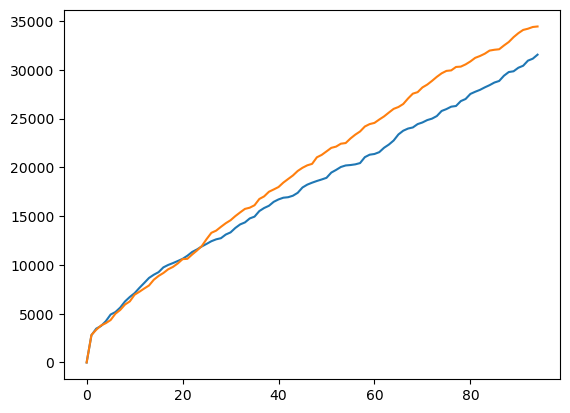

In [60]:
fig, ax = plt.subplots()
pipeline_direcs = sorted(get_immediate_subdirs(RESULTS_DIR))
for pdirec in pipeline_direcs:
    expenses = []
    for j in range(3):
        direc = pdirec+f"/{j}"
        try:
            expense = np.load(direc+"/expense.npy")
            expenses.append(expense)
        except FileNotFoundError:
            warnings.warn(f"No expense file found for {direc}, run may not have finished.")
    avg_expense = np.asarray(expenses).mean(axis=0)
    ax.plot(
        np.arange(avg_expense.shape[0]), 
        avg_expense,
        label = f"{pdirec}"
    )
ax.set_xlabel("Number of iterations")
ax.set_ylabel("Estimated Expense (a.u.)")
ax.legend()
plt.show()